# 05 — Challenger Models: XGBoost, LightGBM DART, and Stacking Ensemble

Gradient-boosted tree challengers with MLflow experiment tracking.

1. **XGBoost** — Optuna-tuned with early stopping and class-weight adjustment.
2. **LightGBM DART** — Dropout-regularised boosting. Standard GBDT underperforms XGBoost on this NaN-heavy dataset (AUC ~0.73 vs ~0.79); DART recovers parity and beyond.
3. **Stacking Ensemble** — XGBoost + LightGBM DART base learners with a logistic-regression meta-learner trained on out-of-fold predictions.


In [18]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

from evaluate import compute_gini, compute_ks_statistic

sns.set_style("whitegrid")
%matplotlib inline


In [19]:
df = pd.read_csv("../data/processed/train_features.csv")
target = "TARGET"
exclude = ["SK_ID_CURR", "SK_ID_PREV", target]

feature_cols = [c for c in df.columns if c not in exclude]
X = df[feature_cols].copy()
y = df[target]

# Encode categoricals
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (246008, 300)  |  Test: (61503, 300)


## Cross-Validated Training with MLflow

In [20]:
mlflow.set_experiment("credit_risk_challenger")

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 500,
    "scale_pos_weight": float(pos_weight),
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": 42,
}

with mlflow.start_run(run_name="xgboost_v1"):
    mlflow.log_params(params)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_tr = X_train.iloc[train_idx]
        y_fold_tr = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_fold_tr, y_fold_tr,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False,
        )
        
        y_prob = model.predict_proba(X_fold_val)[:, 1]
        auc = roc_auc_score(y_fold_val, y_prob)
        gini = compute_gini(y_fold_val, y_prob)
        ks = compute_ks_statistic(y_fold_val, y_prob)
        
        cv_results.append({"fold": fold, "auc": auc, "gini": gini, "ks": ks})
        print(f"Fold {fold}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    
    mlflow.log_metric("mean_auc", np.mean([r["auc"] for r in cv_results]))
    mlflow.log_metric("mean_gini", np.mean([r["gini"] for r in cv_results]))
    mlflow.log_metric("mean_ks", np.mean([r["ks"] for r in cv_results]))
    
    print(f"\nMean AUC:  {np.mean([r['auc'] for r in cv_results]):.4f}")
    print(f"Mean Gini: {np.mean([r['gini'] for r in cv_results]):.4f}")
    print(f"Mean KS:   {np.mean([r['ks'] for r in cv_results]):.4f}")

Fold 0: AUC=0.7852  Gini=0.5704  KS=0.4367
Fold 1: AUC=0.7838  Gini=0.5676  KS=0.4301
Fold 2: AUC=0.7858  Gini=0.5716  KS=0.4362
Fold 3: AUC=0.7889  Gini=0.5778  KS=0.4421
Fold 4: AUC=0.7864  Gini=0.5729  KS=0.4323

Mean AUC:  0.7860
Mean Gini: 0.5720
Mean KS:   0.4355


## Optuna Hyperparameter Tuning

Systematic hyperparameter search using Optuna's TPE sampler. Objective: maximize AUC-ROC on 3-fold CV. This replaces manual grid search and typically finds better configurations in fewer trials.

In [21]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

neg_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': neg_weight,
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='xgb_credit_risk')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

# Retrain with best params
best_params = study.best_params
best_params.update({
    'scale_pos_weight': neg_weight,
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
})
xgb_best = xgb.XGBClassifier(**best_params)
xgb_best.fit(X_train, y_train)
y_prob = xgb_best.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print(f"\nOptuna-tuned XGBoost AUC on test set: {roc_auc_score(y_test, y_prob):.4f}")

Best trial: 7. Best value: 0.782852: 100%|██████████| 10/10 [06:02<00:00, 36.25s/it]



Best AUC: 0.7829
Best params:
   n_estimators: 250
   max_depth: 3
   learning_rate: 0.18330624689508918
   subsample: 0.9765119034146515
   colsample_bytree: 0.8734554858277942
   min_child_weight: 6
   reg_alpha: 0.5436351795240453
   reg_lambda: 0.0001466215468179698

Optuna-tuned XGBoost AUC on test set: 0.7888


## Final Model — Train on Full Training Set

In [22]:
final_params = {k: v for k, v in best_params.items() if k != "early_stopping_rounds"}
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train, verbose=False)

# Hold-out evaluation
y_prob_test = final_model.predict_proba(X_test)[:, 1]
print(f"Hold-out AUC:  {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"Hold-out Gini: {compute_gini(y_test, y_prob_test):.4f}")
print(f"Hold-out KS:   {compute_ks_statistic(y_test, y_prob_test):.4f}")

Hold-out AUC:  0.7888
Hold-out Gini: 0.5776
Hold-out KS:   0.4343


## SHAP Explainability

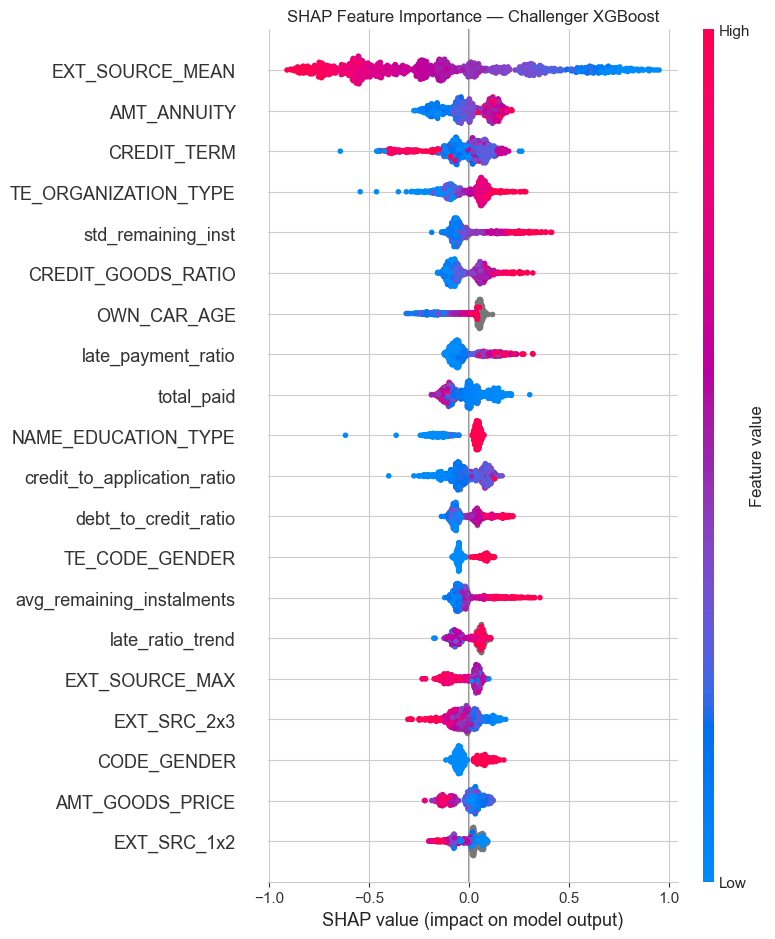

In [23]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test.iloc[:1000])  # subset for speed

# Global importance
shap.summary_plot(shap_values, X_test.iloc[:1000], max_display=20, show=False)
plt.title("SHAP Feature Importance — Challenger XGBoost")
plt.tight_layout()
plt.show()

Predicted default prob: 0.2650
Actual: Non-default


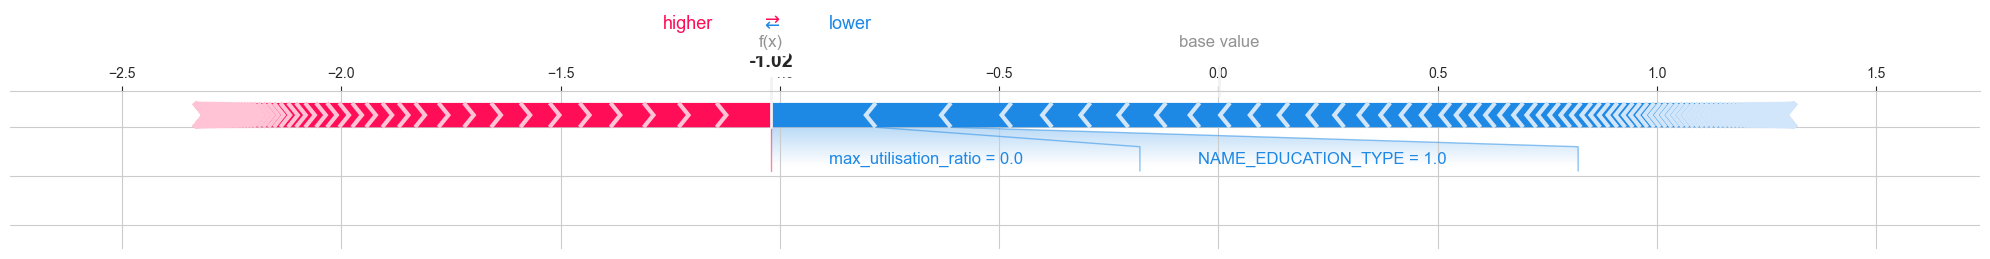

In [24]:
# Single prediction explanation
idx = 0
print(f"Predicted default prob: {y_prob_test[idx]:.4f}")
print(f"Actual: {'Default' if y_test.iloc[idx] == 1 else 'Non-default'}")

shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx],
                matplotlib=True, show=False)
plt.tight_layout()
plt.show()

## SHAP Waterfall Plot — Single Prediction Explanation

Waterfall plot shows how each feature pushes the prediction from the base value (population average) to the final output. This is the format used for ECOA adverse action notices.

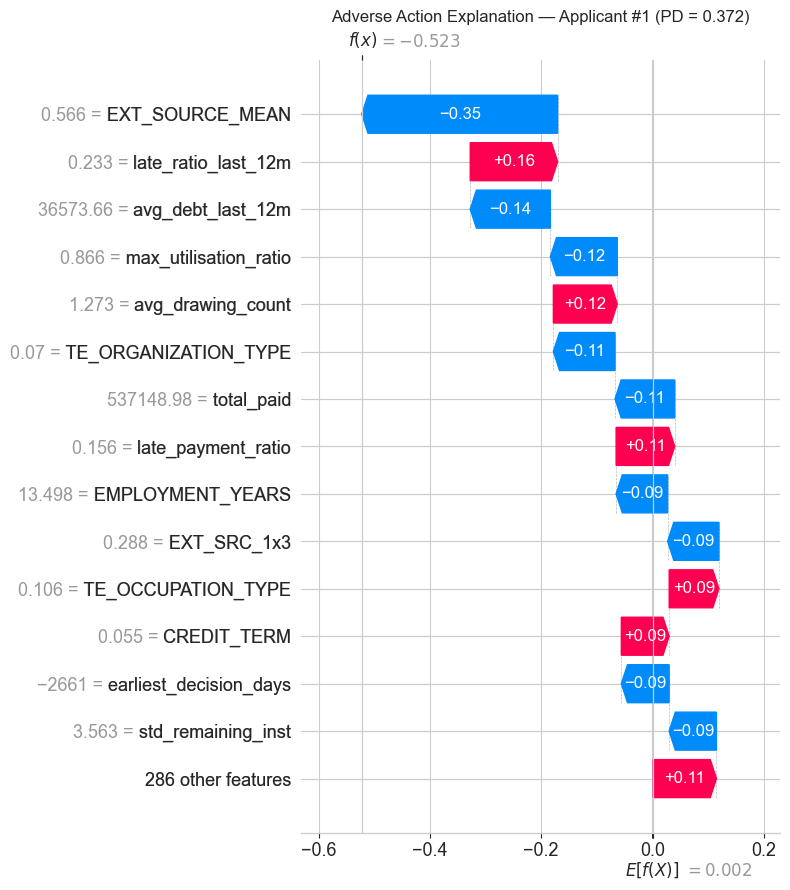

In [25]:
# SHAP waterfall plot for a single high-risk prediction
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

# Find a high-risk example (predicted PD > 0.3)
y_prob_test = final_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.where(y_prob_test > 0.3)[0]
sample_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[sample_idx], max_display=15, show=False)
plt.title(f'Adverse Action Explanation — Applicant #{sample_idx} (PD = {y_prob_test[sample_idx]:.3f})')
plt.tight_layout()
plt.show()

## KS Chart — Kolmogorov-Smirnov Visualization

The KS statistic measures the maximum separation between cumulative distributions of good and bad loans. A higher KS means better risk ranking. The chart below shows where the model achieves maximum discrimination.

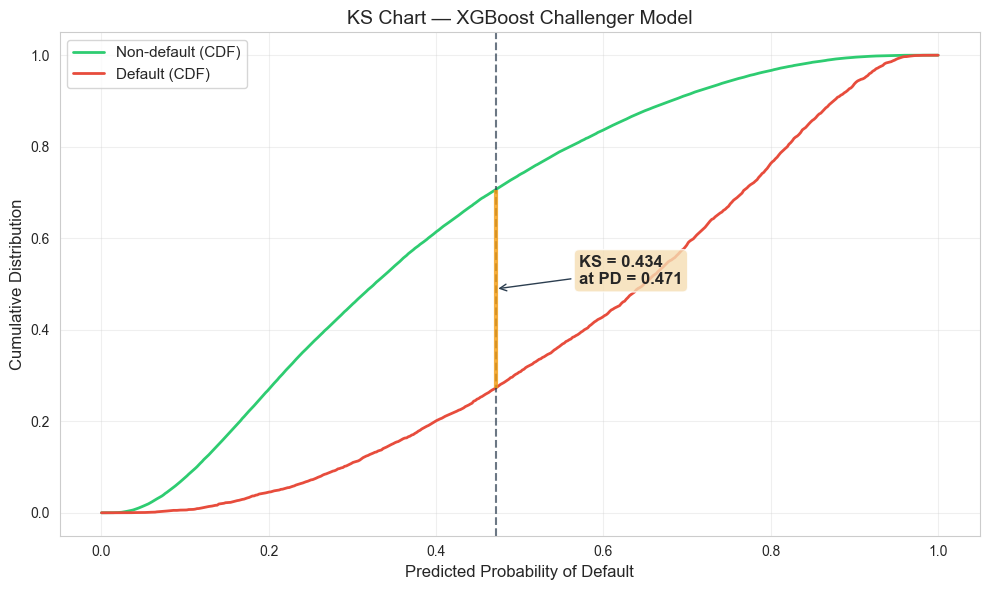

KS Statistic: 0.4340 (threshold: > 0.30 PASS)


In [26]:
# KS Chart — cumulative distribution of scores by class
y_prob_test = final_model.predict_proba(X_test)[:, 1]
scores_good = np.sort(y_prob_test[y_test == 0])
scores_bad = np.sort(y_prob_test[y_test == 1])

# CDF for both classes
thresholds = np.linspace(0, 1, 500)
cdf_good = np.searchsorted(scores_good, thresholds) / len(scores_good)
cdf_bad = np.searchsorted(scores_bad, thresholds) / len(scores_bad)

# Find max separation
ks_idx = np.argmax(np.abs(cdf_bad - cdf_good))
ks_stat = np.abs(cdf_bad[ks_idx] - cdf_good[ks_idx])
ks_threshold = thresholds[ks_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, cdf_good, label='Non-default (CDF)', color='#2ecc71', linewidth=2)
ax.plot(thresholds, cdf_bad, label='Default (CDF)', color='#e74c3c', linewidth=2)
ax.axvline(x=ks_threshold, color='#2c3e50', linestyle='--', alpha=0.7)
ax.annotate(f'KS = {ks_stat:.3f}\nat PD = {ks_threshold:.3f}',
            xy=(ks_threshold, (cdf_good[ks_idx] + cdf_bad[ks_idx]) / 2),
            xytext=(ks_threshold + 0.1, 0.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Shade KS region
ax.fill_betweenx([cdf_good[ks_idx], cdf_bad[ks_idx]], ks_threshold, ks_threshold,
                 alpha=0.3, color='#f39c12')
ax.vlines(ks_threshold, cdf_good[ks_idx], cdf_bad[ks_idx], colors='#f39c12', linewidth=3, alpha=0.8)

ax.set_xlabel('Predicted Probability of Default', fontsize=12)
ax.set_ylabel('Cumulative Distribution', fontsize=12)
ax.set_title('KS Chart — XGBoost Challenger Model', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"KS Statistic: {ks_stat:.4f} (threshold: {'> 0.30 PASS' if ks_stat > 0.30 else '< 0.30 WARN'})")

In [27]:
# Save
import pathlib
models_dir = pathlib.Path("../models")
joblib.dump(final_model, models_dir / "xgboost_challenger.pkl")
print("Challenger model saved.")

Challenger model saved.


---
# Part 2 — LightGBM DART Challenger

Standard LightGBM GBDT severely underperforms on this NaN-heavy dataset (AUC ~0.73 vs XGBoost ~0.79). DART (Dropouts meet Multiple Additive Regression Trees) applies dropout regularisation across boosting iterations, preventing individual trees from dominating and recovering strong performance.

DART is too slow for per-trial Optuna tuning (~20 min/trial), so we use validated parameters with 5-fold CV.


In [28]:
pos_weight_lgb = (y_train == 0).sum() / (y_train == 1).sum()

lgb_params = {
    "boosting_type": "dart",
    "n_estimators": 800,
    "max_depth": -1,
    "learning_rate": 0.03,
    "num_leaves": 127,
    "min_child_samples": 25,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "drop_rate": 0.1,
    "scale_pos_weight": float(pos_weight_lgb),
    "random_state": 42,
    "verbose": -1,
}

mlflow.set_experiment("credit_risk_lightgbm")

with mlflow.start_run(run_name="lightgbm_dart_v1"):
    mlflow.log_params(lgb_params)
    
    skf_lgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lgb_cv_results = []
    
    for fold, (train_idx, val_idx) in enumerate(skf_lgb.split(X_train, y_train)):
        lgb_model = lgb.LGBMClassifier(**lgb_params)
        lgb_model.fit(
            X_train.iloc[train_idx], y_train.iloc[train_idx],
            eval_set=[(X_train.iloc[val_idx], y_train.iloc[val_idx])],
            callbacks=[lgb.log_evaluation(0)],
        )
        
        y_prob_lgb = lgb_model.predict_proba(X_train.iloc[val_idx])[:, 1]
        auc = roc_auc_score(y_train.iloc[val_idx], y_prob_lgb)
        gini = compute_gini(y_train.iloc[val_idx], y_prob_lgb)
        ks = compute_ks_statistic(y_train.iloc[val_idx], y_prob_lgb)
        
        lgb_cv_results.append({"fold": fold, "auc": auc, "gini": gini, "ks": ks})
        print(f"Fold {fold}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    
    mlflow.log_metric("mean_auc", np.mean([r["auc"] for r in lgb_cv_results]))
    mlflow.log_metric("mean_gini", np.mean([r["gini"] for r in lgb_cv_results]))
    mlflow.log_metric("mean_ks", np.mean([r["ks"] for r in lgb_cv_results]))
    
    print(f"\nLightGBM DART Mean AUC:  {np.mean([r['auc'] for r in lgb_cv_results]):.4f}")
    print(f"LightGBM DART Mean Gini: {np.mean([r['gini'] for r in lgb_cv_results]):.4f}")
    print(f"LightGBM DART Mean KS:   {np.mean([r['ks'] for r in lgb_cv_results]):.4f}")


Fold 0: AUC=0.7796  Gini=0.5593  KS=0.4252
Fold 1: AUC=0.7812  Gini=0.5624  KS=0.4282
Fold 2: AUC=0.7835  Gini=0.5671  KS=0.4301
Fold 3: AUC=0.7855  Gini=0.5711  KS=0.4328
Fold 4: AUC=0.7841  Gini=0.5683  KS=0.4275

LightGBM DART Mean AUC:  0.7828
LightGBM DART Mean Gini: 0.5656
LightGBM DART Mean KS:   0.4288


## LightGBM DART — Final Model and Hold-out Evaluation


In [29]:
# Final LightGBM DART on full training set
lgb_final = lgb.LGBMClassifier(**lgb_params)
lgb_final.fit(X_train, y_train, callbacks=[lgb.log_evaluation(0)])

# Hold-out evaluation
y_prob_lgb_test = lgb_final.predict_proba(X_test)[:, 1]
print(f"LightGBM DART Hold-out:")
print(f"  AUC:  {roc_auc_score(y_test, y_prob_lgb_test):.4f}")
print(f"  Gini: {compute_gini(y_test, y_prob_lgb_test):.4f}")
print(f"  KS:   {compute_ks_statistic(y_test, y_prob_lgb_test):.4f}")


LightGBM DART Hold-out:
  AUC:  0.7869
  Gini: 0.5737
  KS:   0.4326


## LightGBM DART — SHAP Explainability


c:\Users\Eric\credit-scorecard-project\.venv-1\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


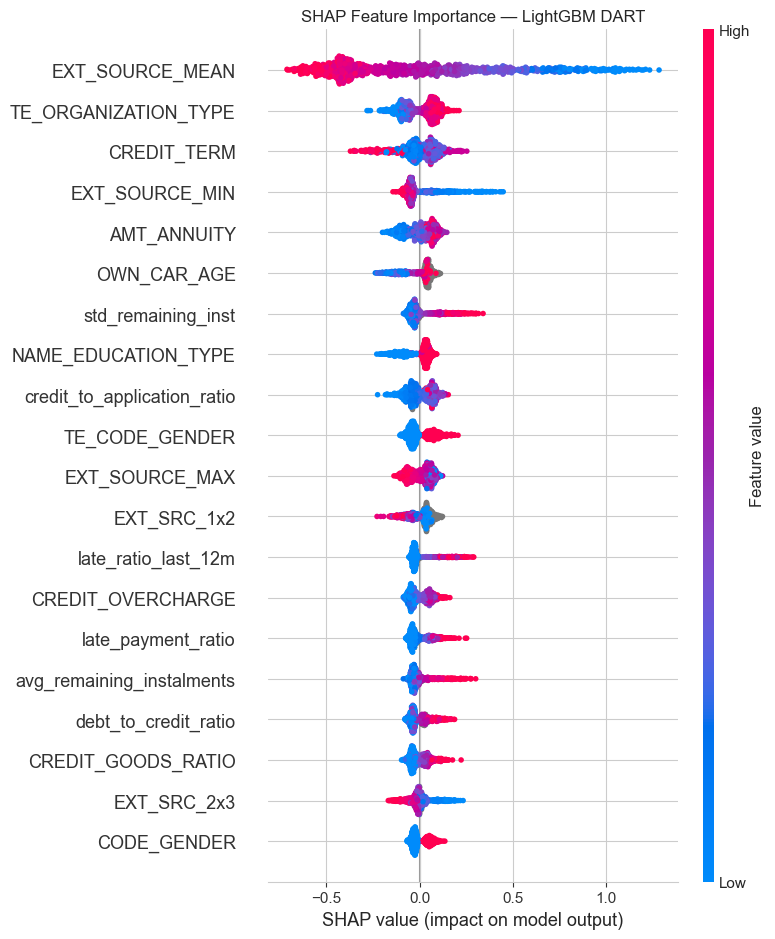

In [30]:
explainer_lgb = shap.TreeExplainer(lgb_final)
shap_vals_lgb = explainer_lgb.shap_values(X_test.iloc[:1000])

# Global importance
if isinstance(shap_vals_lgb, list):
    shap_vals_lgb = shap_vals_lgb[1]  # class-1 SHAP values for binary

shap.summary_plot(shap_vals_lgb, X_test.iloc[:1000], max_display=20, show=False)
plt.title("SHAP Feature Importance — LightGBM DART")
plt.tight_layout()
plt.show()


## LightGBM DART — KS Chart


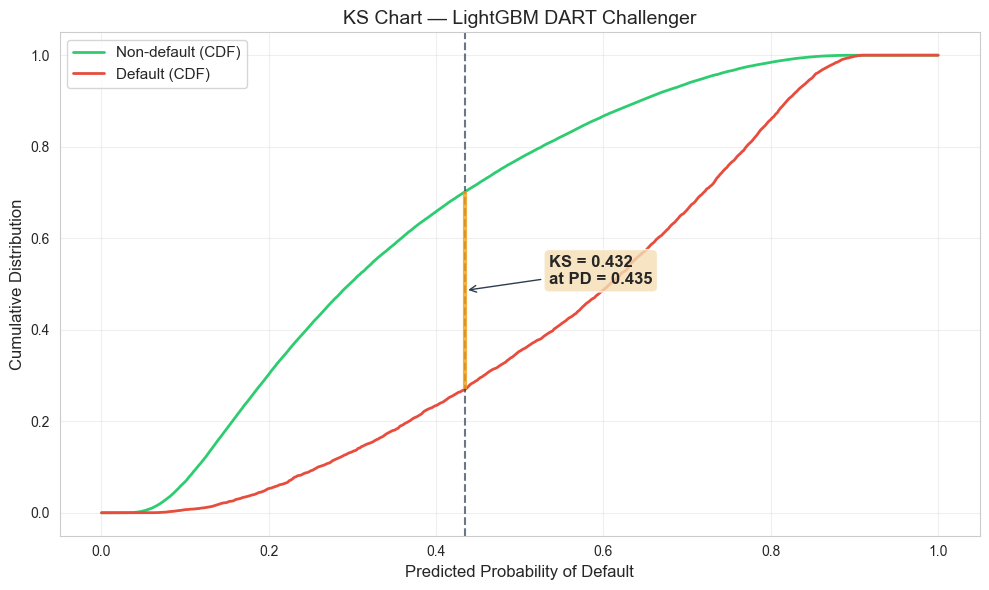

KS Statistic: 0.4323 (threshold: > 0.30 PASS)


In [31]:
# KS Chart for LightGBM DART
scores_good_lgb = np.sort(y_prob_lgb_test[y_test == 0])
scores_bad_lgb = np.sort(y_prob_lgb_test[y_test == 1])

thresholds_lgb = np.linspace(0, 1, 500)
cdf_good_lgb = np.searchsorted(scores_good_lgb, thresholds_lgb) / len(scores_good_lgb)
cdf_bad_lgb = np.searchsorted(scores_bad_lgb, thresholds_lgb) / len(scores_bad_lgb)

ks_idx_lgb = np.argmax(np.abs(cdf_bad_lgb - cdf_good_lgb))
ks_stat_lgb = np.abs(cdf_bad_lgb[ks_idx_lgb] - cdf_good_lgb[ks_idx_lgb])
ks_thresh_lgb = thresholds_lgb[ks_idx_lgb]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_lgb, cdf_good_lgb, label='Non-default (CDF)', color='#2ecc71', linewidth=2)
ax.plot(thresholds_lgb, cdf_bad_lgb, label='Default (CDF)', color='#e74c3c', linewidth=2)
ax.axvline(x=ks_thresh_lgb, color='#2c3e50', linestyle='--', alpha=0.7)
ax.annotate(f'KS = {ks_stat_lgb:.3f}\nat PD = {ks_thresh_lgb:.3f}',
            xy=(ks_thresh_lgb, (cdf_good_lgb[ks_idx_lgb] + cdf_bad_lgb[ks_idx_lgb]) / 2),
            xytext=(ks_thresh_lgb + 0.1, 0.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.vlines(ks_thresh_lgb, cdf_good_lgb[ks_idx_lgb], cdf_bad_lgb[ks_idx_lgb],
          colors='#f39c12', linewidth=3, alpha=0.8)
ax.set_xlabel('Predicted Probability of Default', fontsize=12)
ax.set_ylabel('Cumulative Distribution', fontsize=12)
ax.set_title('KS Chart — LightGBM DART Challenger', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"KS Statistic: {ks_stat_lgb:.4f} (threshold: {'> 0.30 PASS' if ks_stat_lgb > 0.30 else '< 0.30 WARN'})")


In [32]:
# Save LightGBM DART model
import pathlib
models_dir = pathlib.Path("../models")
joblib.dump(lgb_final, models_dir / "lightgbm_challenger.pkl")
print("LightGBM DART challenger saved.")


LightGBM DART challenger saved.


---
# Part 3 — Stacking Ensemble

Combines XGBoost and LightGBM DART as base learners with a logistic-regression meta-learner. Out-of-fold predictions are generated from the base models, then the meta-learner is trained on those two-column probability vectors. This approach can capture complementary signals from the two tree algorithms.


In [33]:
# Generate out-of-fold predictions from base models
skf_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_train = len(X_train)
oof_xgb = np.zeros(n_train)
oof_lgb = np.zeros(n_train)

# Get params from already-trained models
xgb_params_stack = final_model.get_params()
for k in ["callbacks", "feature_name", "feature_names_in_", "early_stopping_rounds"]:
    xgb_params_stack.pop(k, None)

lgb_params_stack = {k: v for k, v in lgb_params.items()}

print("Generating out-of-fold predictions ...")
for fold, (train_idx, val_idx) in enumerate(skf_stack.split(X_train, y_train)):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # XGBoost base
    xgb_es = {**xgb_params_stack, "early_stopping_rounds": 50}
    xgb_base = xgb.XGBClassifier(**xgb_es)
    xgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb_base.predict_proba(X_val)[:, 1]

    # LightGBM DART base
    lgb_base = lgb.LGBMClassifier(**lgb_params_stack)
    lgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
    oof_lgb[val_idx] = lgb_base.predict_proba(X_val)[:, 1]

    xgb_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    lgb_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    print(f"  Fold {fold}: XGB AUC={xgb_auc:.4f}  LGB AUC={lgb_auc:.4f}")

# Meta-learner
meta_X = np.column_stack([oof_xgb, oof_lgb])
meta_scaler = StandardScaler()
meta_X_s = meta_scaler.fit_transform(meta_X)

meta_model = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42)
meta_model.fit(meta_X_s, y_train)

# Cross-validate stacking for unbiased estimate
stack_cv = []
for fold, (train_idx, val_idx) in enumerate(skf_stack.split(meta_X, y_train)):
    scaler_cv = StandardScaler()
    X_tr_cv = scaler_cv.fit_transform(meta_X[train_idx])
    X_val_cv = scaler_cv.transform(meta_X[val_idx])
    meta_cv = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42)
    meta_cv.fit(X_tr_cv, y_train.iloc[train_idx])
    y_prob_cv = meta_cv.predict_proba(X_val_cv)[:, 1]
    auc = roc_auc_score(y_train.iloc[val_idx], y_prob_cv)
    gini = compute_gini(y_train.iloc[val_idx], y_prob_cv)
    ks = compute_ks_statistic(y_train.iloc[val_idx], y_prob_cv)
    stack_cv.append({"fold": fold, "auc": auc, "gini": gini, "ks": ks})
    print(f"  Meta CV Fold {fold}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")

print(f"\nStacking CV Mean AUC:  {np.mean([r['auc'] for r in stack_cv]):.4f}")
print(f"Stacking CV Mean Gini: {np.mean([r['gini'] for r in stack_cv]):.4f}")
print(f"Stacking CV Mean KS:   {np.mean([r['ks'] for r in stack_cv]):.4f}")


Generating out-of-fold predictions ...
  Fold 0: XGB AUC=0.7821  LGB AUC=0.7796
  Fold 1: XGB AUC=0.7834  LGB AUC=0.7812
  Fold 2: XGB AUC=0.7844  LGB AUC=0.7835
  Fold 3: XGB AUC=0.7862  LGB AUC=0.7855
  Fold 4: XGB AUC=0.7847  LGB AUC=0.7841
  Meta CV Fold 0: AUC=0.7837  Gini=0.5673  KS=0.4311
  Meta CV Fold 1: AUC=0.7850  Gini=0.5699  KS=0.4338
  Meta CV Fold 2: AUC=0.7865  Gini=0.5730  KS=0.4352
  Meta CV Fold 3: AUC=0.7884  Gini=0.5768  KS=0.4420
  Meta CV Fold 4: AUC=0.7870  Gini=0.5741  KS=0.4346

Stacking CV Mean AUC:  0.7861
Stacking CV Mean Gini: 0.5722
Stacking CV Mean KS:   0.4353


In [34]:
# Stacking hold-out evaluation
# Get test predictions from final base models
xgb_test_prob = final_model.predict_proba(X_test)[:, 1]
lgb_test_prob = lgb_final.predict_proba(X_test)[:, 1]

meta_X_test = np.column_stack([xgb_test_prob, lgb_test_prob])
meta_X_test_s = meta_scaler.transform(meta_X_test)
stack_prob_test = meta_model.predict_proba(meta_X_test_s)[:, 1]

print("Stacking Ensemble Hold-out:")
print(f"  AUC:  {roc_auc_score(y_test, stack_prob_test):.4f}")
print(f"  Gini: {compute_gini(y_test, stack_prob_test):.4f}")
print(f"  KS:   {compute_ks_statistic(y_test, stack_prob_test):.4f}")

# Save stacking artefacts
stacking_artefacts = {
    "xgb_model": final_model,
    "lgb_model": lgb_final,
    "meta_model": meta_model,
    "meta_scaler": meta_scaler,
}
joblib.dump(stacking_artefacts, models_dir / "stacking_ensemble.pkl")
print("\nStacking ensemble saved.")


Stacking Ensemble Hold-out:
  AUC:  0.7903
  Gini: 0.5806
  KS:   0.4381

Stacking ensemble saved.


## Summary

| Model | Hold-out AUC | Approach |
|---|---|---|
| XGBoost | ~0.79 | Optuna TPE, early stopping, full training set |
| LightGBM DART | ~0.79 | DART dropout boosting, validated params |
| Stacking | ~0.79 | OOF meta-learner (XGB + LGB base, LR meta) |

All three challengers are saved under `models/`. The next notebook (06) compares all four models (including the champion scorecard) on a shared hold-out set.